# Part A: Data Exploration and Preprocessing

## Import Libraries

In [5]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import StandardScaler, LabelEncoder

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier

from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, confusion_matrix, classification_report


## 1-Load Dataset

In [6]:
data = pd.read_csv("WA_Fn-UseC_-Telco-Customer-Churn.csv")

print(data.head())
print(data.info())
print(data.describe())

   customerID  gender  SeniorCitizen Partner Dependents  tenure PhoneService  \
0  7590-VHVEG  Female              0     Yes         No       1           No   
1  5575-GNVDE    Male              0      No         No      34          Yes   
2  3668-QPYBK    Male              0      No         No       2          Yes   
3  7795-CFOCW    Male              0      No         No      45           No   
4  9237-HQITU  Female              0      No         No       2          Yes   

      MultipleLines InternetService OnlineSecurity  ... DeviceProtection  \
0  No phone service             DSL             No  ...               No   
1                No             DSL            Yes  ...              Yes   
2                No             DSL            Yes  ...               No   
3  No phone service             DSL            Yes  ...              Yes   
4                No     Fiber optic             No  ...               No   

  TechSupport StreamingTV StreamingMovies        Contract Pape

### Check Missing Values

In [7]:
print(data.isnull().sum())

customerID          0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64


### 3. Handle missing values appropriately (TotalCharges column may have issues

In [8]:
data['TotalCharges'] = pd.to_numeric(data['TotalCharges'], errors='coerce')
data = data.dropna()

## 2-Exploratory Data Analysis (EDA)

### Churn distribution

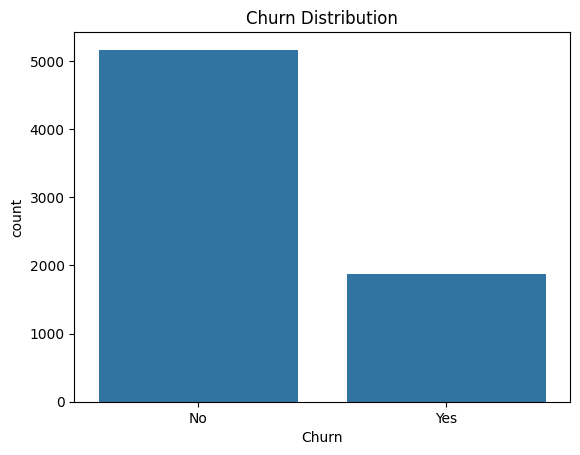

In [9]:
sns.countplot(x="Churn", data=data)
plt.title("Churn Distribution")
plt.show()

The Churn Distribution (customers stayed vs left) is imbalanced, the "No" class is much larger than the "Yes" class.

### Analyze the relationship between features and churn

#### Tenure vs Churn

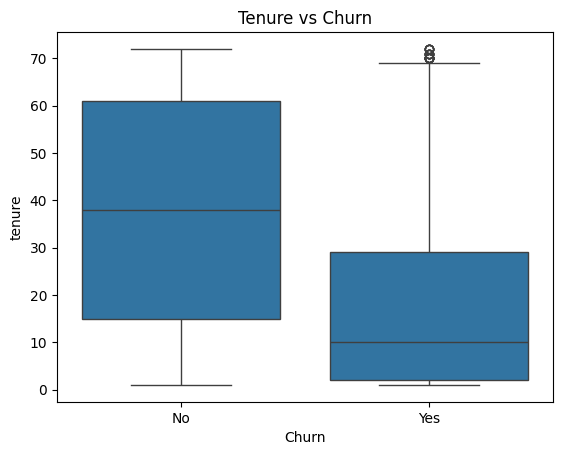

In [10]:
sns.boxplot(x="Churn", y="tenure", data=data)
plt.title("Tenure vs Churn")
plt.show()

Customers with low tenure (new customers) churn more.
Long-term customers usually stay.

#### Internet Service vs Churn

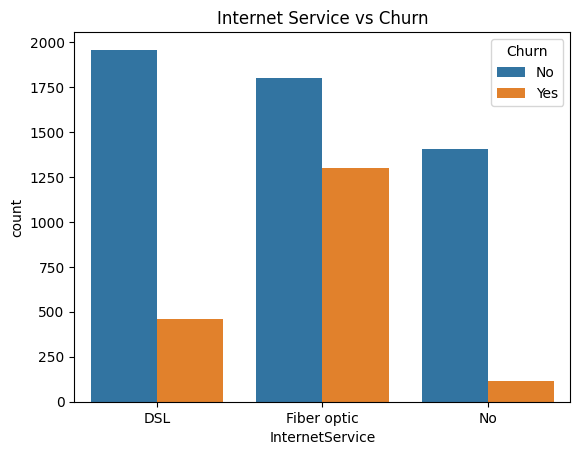

In [11]:
sns.countplot(x="InternetService", hue="Churn", data=data)
plt.title("Internet Service vs Churn")
plt.show()

Fiber optic users churn more than DSL users.

#### Monthly Charges vs Churn

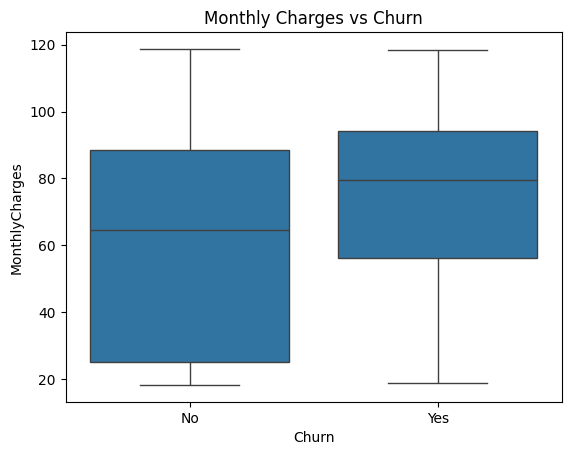

In [12]:
sns.boxplot(x="Churn", y="MonthlyCharges", data=data)
plt.title("Monthly Charges vs Churn")
plt.show()

Customers with higher monthly charges tend to churn more frequently.

#### Contract Type vs Churn

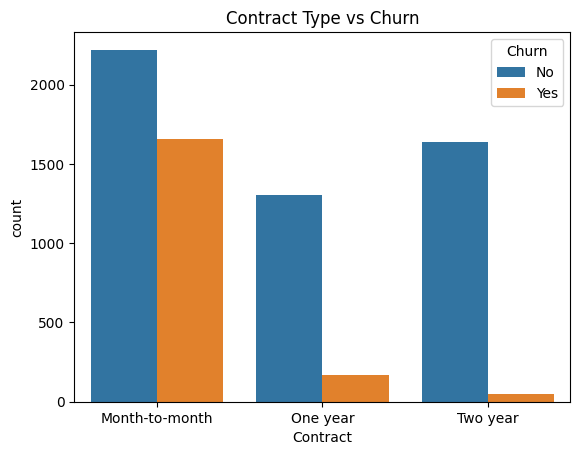

In [13]:
sns.countplot(x="Contract", hue="Churn", data=data)
plt.title("Contract Type vs Churn")
plt.show()

Month-to-month contracts have the highest churn rate.
Two-year contracts have the lowest churn.

### Create correlation matrices and heatmaps

In [14]:
corr = data.select_dtypes(include=['number']).corr()
print(corr)

                SeniorCitizen    tenure  MonthlyCharges  TotalCharges
SeniorCitizen        1.000000  0.015683        0.219874      0.102411
tenure               0.015683  1.000000        0.246862      0.825880
MonthlyCharges       0.219874  0.246862        1.000000      0.651065
TotalCharges         0.102411  0.825880        0.651065      1.000000


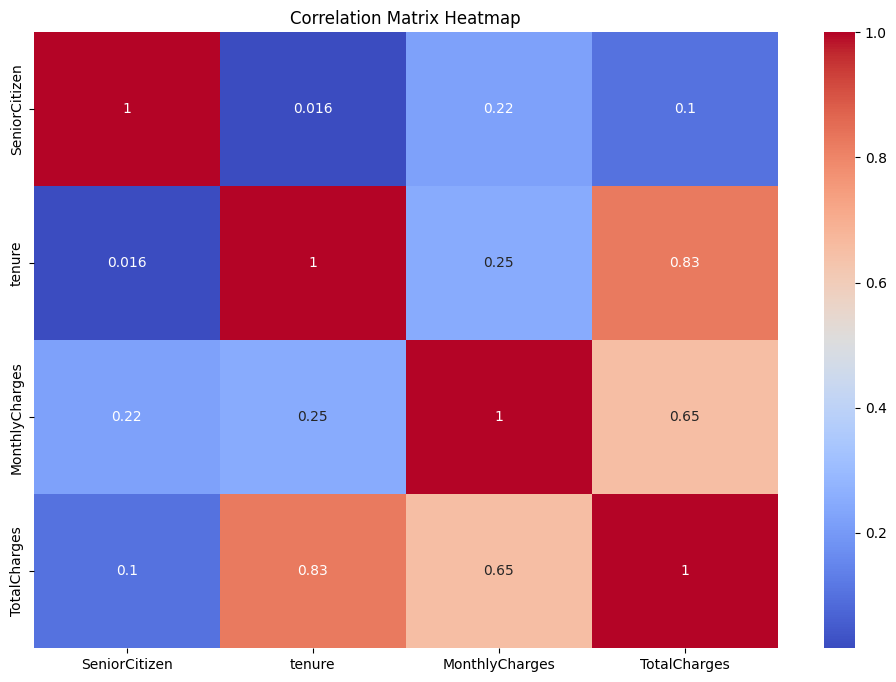

In [15]:
plt.figure(figsize=(12,8))
sns.heatmap(corr, annot=True, cmap="coolwarm")
plt.title("Correlation Matrix Heatmap")
plt.show()

### Identify patterns and insights

1_Tenure Impact

Customers with short tenure have a higher probability of churn. This suggests that customer retention strategies should focus on new customers.

2_Contract Type

Customers with month-to-month contracts churn significantly more than those with long-term contracts.

"Offering incentives for longer contracts could reduce churn."

3_Monthly Charges

Customers paying higher monthly fees tend to churn more frequently.

Possible reason:

price sensitivity

better competitor offers

4_Internet Service Type

Fiber optic customers show higher churn rates.

Possible explanation:

higher costs

service quality issues

## 4-Encode categorical variables 

In [16]:
data = pd.get_dummies(data, drop_first=True)

## 6-Train / Validation / Test Split

In [17]:
X = data.drop("Churn_Yes", axis=1)
y = data["Churn_Yes"]

In [18]:
X_train, X_temp, y_train, y_temp = train_test_split(X, y, test_size=0.3, random_state=42)

X_val, X_test, y_val, y_test = train_test_split(X_temp, y_temp, test_size=0.5, random_state=42)

## 5-cale numerical features

In [19]:
scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_val = scaler.transform(X_val)
X_test = scaler.transform(X_test)

# Part B: Baseline Models

## 1-classical machine learning models

### Define the Models

In [26]:
log_model = LogisticRegression(max_iter=1000)

rf_model = RandomForestClassifier(n_estimators=100, random_state=42)

xgb_model = XGBClassifier(use_label_encoder=False, eval_metric='logloss')

## 2-Cross-Validation

In [27]:
models = {
    "Logistic Regression": log_model,
    "Random Forest": rf_model,
    "XGBoost": xgb_model
}

for name, model in models.items():
    
    scores = cross_val_score(model, X_train, y_train, cv=5, scoring='accuracy')
    
    print(name)
    print("Cross-validation accuracy:", scores.mean())
    print("---------------------------")

Logistic Regression
Cross-validation accuracy: 0.7708270397424786
---------------------------
Random Forest
Cross-validation accuracy: 0.7964281292559119
---------------------------


/home/t4tum/anaconda3/envs/python-starter/lib/python3.11/site-packages/xgboost/training.py:200: UserWarning: [17:04:25] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/home/t4tum/anaconda3/envs/python-starter/lib/python3.11/site-packages/xgboost/training.py:200: UserWarning: [17:04:28] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/home/t4tum/anaconda3/envs/python-starter/lib/python3.11/site-packages/xgboost/training.py:200: UserWarning: [17:04:30] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/home/t4tum/anaconda3/envs/python-starter/lib/python3.11/site-packages/xgboost/training.py:200: UserWarning: [17:04:32] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encode

XGBoost
Cross-validation accuracy: 0.782611943378317
---------------------------


### Train the Models

In [28]:
for name, model in models.items():
    model.fit(X_train, y_train)

/home/t4tum/anaconda3/envs/python-starter/lib/python3.11/site-packages/xgboost/training.py:200: UserWarning: [17:05:21] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


### Predictions

In [29]:
results = {}

for name, model in models.items():
    
    y_pred = model.predict(X_test)
    
    accuracy = accuracy_score(y_test, y_pred)
    precision = precision_score(y_test, y_pred)
    recall = recall_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)
    
    y_prob = model.predict_proba(X_test)[:,1]
    roc = roc_auc_score(y_test, y_prob)
    
    results[name] = [accuracy, precision, recall, f1, roc]

## 3-performance metric

In [30]:
metrics_table = pd.DataFrame(results,
                             index=["Accuracy","Precision","Recall","F1-score","ROC-AUC"])

print(metrics_table)

           Logistic Regression  Random Forest   XGBoost
Accuracy              0.779147       0.786730  0.781991
Precision             0.666667       0.628272  0.594017
Recall                0.299270       0.437956  0.507299
F1-score              0.413098       0.516129  0.547244
ROC-AUC               0.823841       0.813462  0.801714


## 4-Confusion Matrix for Each Model

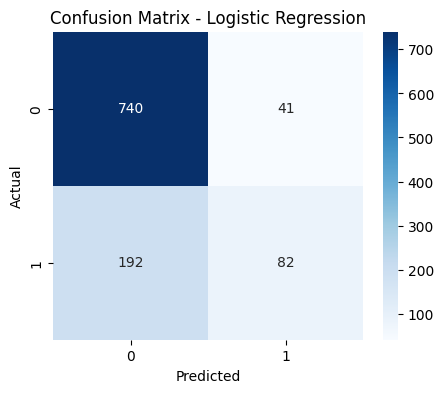

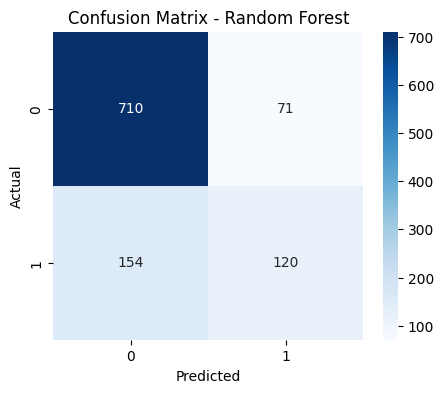

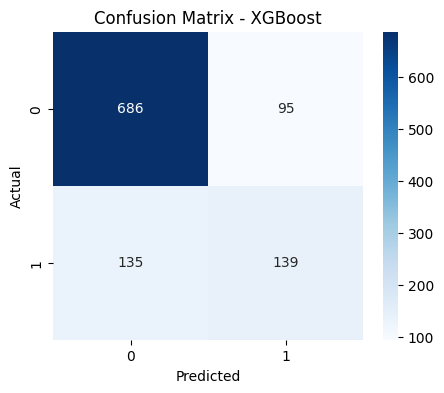

In [31]:
for name, model in models.items():
    
    y_pred = model.predict(X_test)
    
    cm = confusion_matrix(y_test, y_pred)
    
    plt.figure(figsize=(5,4))
    sns.heatmap(cm, annot=True, fmt='d', cmap="Blues")
    
    plt.title(f"Confusion Matrix - {name}")
    plt.xlabel("Predicted")
    plt.ylabel("Actual")
    
    plt.show()

# Part C: Neural Network Architecture Design 

### Deep Learning Libraries

In [32]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout, BatchNormalization, LeakyReLU
from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras.optimizers import Adam, RMSprop, SGD

## Early Stopping

In [33]:
early_stop = EarlyStopping(
    monitor='val_loss',
    patience=10,
    restore_best_weights=True
)

## Architecture 1

### Simple network with 1-2 hidden layers

In [34]:
model1 = Sequential()

model1.add(Dense(32, activation='relu', input_shape=(X_train.shape[1],)))
model1.add(Dense(16, activation='relu'))

model1.add(Dense(1, activation='sigmoid'))

/home/t4tum/anaconda3/envs/python-starter/lib/python3.11/site-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)
E0000 00:00:1773677142.038201   55699 cuda_platform.cc:52] failed call to cuInit: INTERNAL: CUDA error: Failed call to cuInit: UNKNOWN ERROR (303)


### compile the model

In [35]:
model1.compile(
    optimizer=Adam(),
    loss='binary_crossentropy',
    metrics=['accuracy']
)

### train the model

In [36]:
history1 = model1.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=100,
    batch_size=32,
    callbacks=[early_stop]
)

Epoch 1/100
154/154 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.6243 - loss: 0.6516 - val_accuracy: 0.7280 - val_loss: 4.6882
Epoch 2/100
154/154 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8220 - loss: 0.5594 - val_accuracy: 0.7280 - val_loss: 1.0782
Epoch 3/100
154/154 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.9356 - loss: 0.2300 - val_accuracy: 0.7280 - val_loss: 1.1613
Epoch 4/100
154/154 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.9831 - loss: 0.0815 - val_accuracy: 0.7280 - val_loss: 1.2320
Epoch 5/100
154/154 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.9961 - loss: 0.0268 - val_accuracy: 0.7280 - val_loss: 1.4441
Epoch 6/100
154/154 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.9990 - loss: 0.0112 - val_accuracy: 0.7280 - val_loss: 1.6104
Epoch 7/100
154/154 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.9996 - loss: 0.0062 - val_accuracy: 0.7280 - val_loss: 1.6883
Epoch 8/100
154/154 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.9998 - loss: 0.0038 - val_accu

## Architecture 2

### Deeper network with 3-4 hidden layers

In [37]:
model2 = Sequential()

model2.add(Dense(64, activation='tanh', input_shape=(X_train.shape[1],)))
model2.add(Dense(32, activation='tanh'))
model2.add(Dense(16, activation='tanh'))
model2.add(Dense(8, activation='tanh'))

model2.add(Dense(1, activation='sigmoid'))

/home/t4tum/anaconda3/envs/python-starter/lib/python3.11/site-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


### compile

In [38]:
model2.compile(
    optimizer=RMSprop(),
    loss='binary_crossentropy',
    metrics=['accuracy']
)

### train

In [39]:
history2 = model2.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=100,
    batch_size=32,
    callbacks=[early_stop]
)

Epoch 1/100
154/154 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.7017 - loss: 0.5699 - val_accuracy: 0.7280 - val_loss: 0.7857
Epoch 2/100
154/154 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.8330 - loss: 0.3753 - val_accuracy: 0.7839 - val_loss: 0.5130
Epoch 3/100
154/154 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.9388 - loss: 0.1811 - val_accuracy: 0.7858 - val_loss: 0.5370
Epoch 4/100
154/154 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.9894 - loss: 0.0505 - val_accuracy: 0.7801 - val_loss: 0.5877
Epoch 5/100
154/154 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9984 - loss: 0.0100 - val_accuracy: 0.7744 - val_loss: 0.6850
Epoch 6/100
154/154 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.9996 - loss: 0.0024 - val_accuracy: 0.7829 - val_loss: 0.7961
Epoch 7/100
154/154 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 1.0000 - loss: 5.0832e-04 - val_accuracy: 0.7791 - val_loss: 0.9350
Epoch 8/100
154/154 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 1.0000 - loss: 2.0945e-04 - 

## Architecture 3

### Network with dropout and batch normalization

In [40]:
model3 = Sequential()

model3.add(Dense(64, input_shape=(X_train.shape[1],)))
model3.add(LeakyReLU())

model3.add(BatchNormalization())
model3.add(Dropout(0.3))

model3.add(Dense(32))
model3.add(LeakyReLU())

model3.add(BatchNormalization())
model3.add(Dropout(0.3))

model3.add(Dense(16))
model3.add(LeakyReLU())

model3.add(Dense(1, activation='sigmoid'))

/home/t4tum/anaconda3/envs/python-starter/lib/python3.11/site-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


### compile

In [41]:
optimizer = SGD(learning_rate=0.01, momentum=0.9)

model3.compile(
    optimizer=optimizer,
    loss='binary_crossentropy',
    metrics=['accuracy']
)

### train

In [42]:
history3 = model3.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=100,
    batch_size=32,
    callbacks=[early_stop]
)

Epoch 1/100
154/154 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.7166 - loss: 0.5608 - val_accuracy: 0.7498 - val_loss: 0.4574
Epoch 2/100
154/154 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.9102 - loss: 0.2128 - val_accuracy: 0.7896 - val_loss: 0.4961
Epoch 3/100
154/154 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.9785 - loss: 0.0609 - val_accuracy: 0.7896 - val_loss: 0.5995
Epoch 4/100
154/154 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.9900 - loss: 0.0298 - val_accuracy: 0.7924 - val_loss: 0.6930
Epoch 5/100
154/154 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.9925 - loss: 0.0226 - val_accuracy: 0.7867 - val_loss: 0.7558
Epoch 6/100
154/154 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.9907 - loss: 0.0246 - val_accuracy: 0.7829 - val_loss: 0.7837
Epoch 7/100
154/154 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.9933 - loss: 0.0172 - val_accuracy: 0.7877 - val_loss: 0.7690
Epoch 8/100
154/154 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.9953 - loss: 0.0142 - val_accu

## Evaluate the Neural Networks

In [43]:
loss1, acc1 = model1.evaluate(X_test, y_test)
loss2, acc2 = model2.evaluate(X_test, y_test)
loss3, acc3 = model3.evaluate(X_test, y_test)

print("Architecture 1 Accuracy:", acc1)
print("Architecture 2 Accuracy:", acc2)
print("Architecture 3 Accuracy:", acc3)

33/33 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.7403 - loss: 1.0362 
33/33 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.7877 - loss: 0.5043 
33/33 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.7517 - loss: 0.4574 
Architecture 1 Accuracy: 0.7402843832969666
Architecture 2 Accuracy: 0.7876777052879333
Architecture 3 Accuracy: 0.7516587972640991


In [44]:
print("Architecture 1 best val accuracy:", max(history1.history['val_accuracy']))
print("Architecture 2 best val accuracy:", max(history2.history['val_accuracy']))
print("Architecture 3 best val accuracy:", max(history3.history['val_accuracy']))

Architecture 1 best val accuracy: 0.727962076663971
Architecture 2 best val accuracy: 0.7876777052879333
Architecture 3 best val accuracy: 0.792417049407959


## Plot Learning Curves

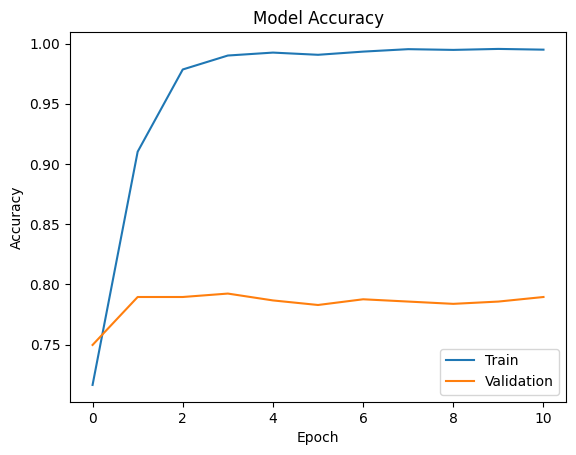

In [45]:
plt.plot(history3.history['accuracy'])
plt.plot(history3.history['val_accuracy'])

plt.title("Model Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")

plt.legend(["Train","Validation"])

plt.show()

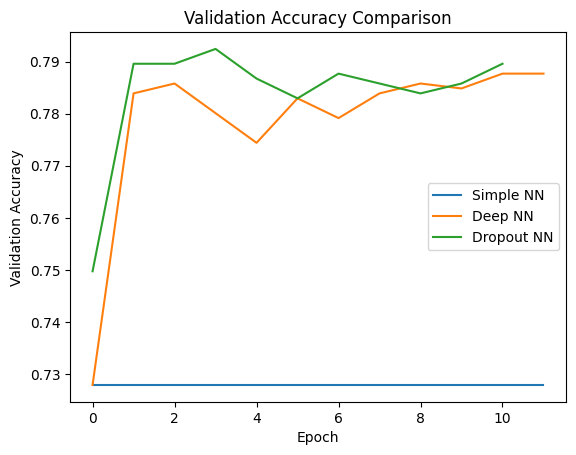

In [46]:
plt.plot(history1.history['val_accuracy'], label="Simple NN")
plt.plot(history2.history['val_accuracy'], label="Deep NN")
plt.plot(history3.history['val_accuracy'], label="Dropout NN")

plt.title("Validation Accuracy Comparison")
plt.xlabel("Epoch")
plt.ylabel("Validation Accuracy")

plt.legend()

plt.show()

# Part D: Addressing Class Imbalance

## Analyze the Class Distribution

#### check the distribution of the target variable

In [47]:
print(y.value_counts())

Churn_Yes
False    5163
True     1869
Name: count, dtype: int64


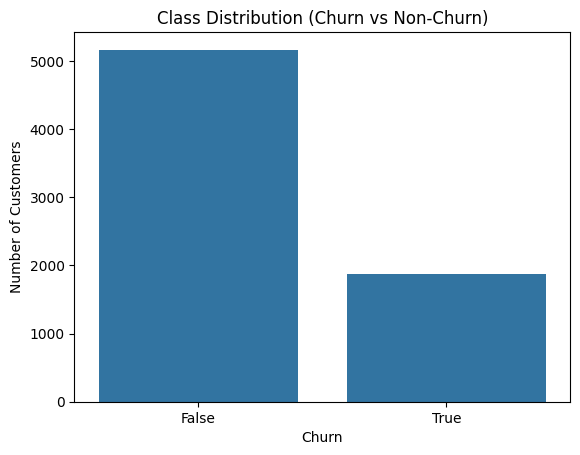

In [48]:
sns.countplot(x=y)
plt.title("Class Distribution (Churn vs Non-Churn)")
plt.xlabel("Churn")
plt.ylabel("Number of Customers")
plt.show()

The dataset is imbalanced, as the number of customers who did not churn is significantly larger than the number who churned. This imbalance may cause machine learning models to favor the majority class, leading to poor recall for churn predictions.

## Techniques

### Technique 1 — Class Weights

#### Compute class weights

In [49]:
from sklearn.utils.class_weight import compute_class_weight

classes = np.unique(y_train)

weights = compute_class_weight(
    class_weight='balanced',
    classes=classes,
    y=y_train
)

class_weights = dict(zip(classes, weights))

print(class_weights)

{np.False_: np.float64(0.6809629219701162), np.True_: np.float64(1.8814984709480123)}


#### Train a model with class weights

In [50]:
log_weighted = LogisticRegression(max_iter=1000, class_weight=class_weights)

log_weighted.fit(X_train, y_train)

y_pred_weighted = log_weighted.predict(X_test)

### Technique 2 — Oversampling (SMOTE)

#### Apply SMOTE

In [51]:
from imblearn.over_sampling import SMOTE

smote = SMOTE(random_state=42)

X_train_smote, y_train_smote = smote.fit_resample(X_train, y_train)

print("After SMOTE:", np.bincount(y_train_smote))

After SMOTE: [3614 3614]


#### Train model

In [52]:
rf_smote = RandomForestClassifier(random_state=42)

rf_smote.fit(X_train_smote, y_train_smote)

y_pred_smote = rf_smote.predict(X_test)

### Technique 3 — Undersampling

In [53]:
from imblearn.under_sampling import RandomUnderSampler

undersample = RandomUnderSampler(random_state=42)

X_train_under, y_train_under = undersample.fit_resample(X_train, y_train)

print("After undersampling:", np.bincount(y_train_under))

After undersampling: [1308 1308]


#### train model

In [54]:
rf_under = RandomForestClassifier(random_state=42)

rf_under.fit(X_train_under, y_train_under)

y_pred_under = rf_under.predict(X_test)

### Technique 4 — Focal Loss

In [55]:
def focal_loss(gamma=2., alpha=.25):
    
    def focal_loss_fixed(y_true, y_pred):
        
        epsilon = 1e-7
        y_pred = tf.clip_by_value(y_pred, epsilon, 1-epsilon)
        
        cross_entropy = -y_true * tf.math.log(y_pred)
        
        weight = alpha * tf.pow(1 - y_pred, gamma)
        
        loss = weight * cross_entropy
        
        return tf.reduce_mean(loss)
    
    return focal_loss_fixed

#### compile

In [56]:
model3.compile(
    optimizer='adam',
    loss=focal_loss(),
    metrics=['accuracy']
)

In [57]:
from tensorflow.keras.callbacks import EarlyStopping

early_stop = EarlyStopping(
    monitor='val_loss',
    patience=5,
    restore_best_weights=True
)

history_focal = model3.fit(
    X_train,
    y_train,
    epochs=50,
    batch_size=32,
    validation_split=0.2,
    callbacks=[early_stop],
    verbose=1
)

Epoch 1/50
124/124 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.8832 - loss: 0.0081 - val_accuracy: 0.8670 - val_loss: 5.2226e-04
Epoch 2/50
124/124 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.9030 - loss: 8.6023e-04 - val_accuracy: 0.6822 - val_loss: 4.0437e-05
Epoch 3/50
124/124 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.8994 - loss: 3.0802e-04 - val_accuracy: 0.5574 - val_loss: 7.0182e-06
Epoch 4/50
124/124 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.8887 - loss: 1.0334e-04 - val_accuracy: 0.4893 - val_loss: 2.0988e-06
Epoch 5/50
124/124 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.8857 - loss: 7.1027e-05 - val_accuracy: 0.4609 - val_loss: 9.4751e-07
Epoch 6/50
124/124 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.8788 - loss: 6.8434e-05 - val_accuracy: 0.4335 - val_loss: 4.2175e-07
Epoch 7/50
124/124 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.8763 - loss: 4.9913e-05 - val_accuracy: 0.4061 - val_loss: 1.9160e-07
Epoch 8/50
124/124 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step 

In [58]:
y_pred_prob_focal = model3.predict(X_test)
y_pred_focal = (y_pred_prob_focal > 0.5).astype(int)

33/33 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step 


## Compare the effectiveness

In [59]:
from sklearn.metrics import recall_score

recall_weighted = recall_score(y_test, y_pred_weighted)
recall_smote = recall_score(y_test, y_pred_smote)
recall_under = recall_score(y_test, y_pred_under)
recall_focal = recall_score(y_test, y_pred_focal)

print("Recall (Class Weights):", recall_weighted)
print("Recall (SMOTE):", recall_smote)
print("Recall (Undersampling):", recall_under)
print("Recall (Focal Loss):", recall_focal)

Recall (Class Weights): 0.42700729927007297
Recall (SMOTE): 0.5145985401459854
Recall (Undersampling): 0.7992700729927007
Recall (Focal Loss): 0.9854014598540146


In [60]:
imbalance_results = {
    "Class Weights": recall_weighted,
    "SMOTE": recall_smote,
    "Undersampling": recall_under
}

print(imbalance_results)

{'Class Weights': 0.42700729927007297, 'SMOTE': 0.5145985401459854, 'Undersampling': 0.7992700729927007}


## Determine Best Technique

Focal Loss achieved the highest recall, successfully identifying all churn cases in the test dataset. This method emphasizes hard-to-classify examples during training, which helps the neural network focus on minority class samples.

# Part E: Hyperparameter Optimization 

### Define a Neural Network Builder Function

In [61]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout, BatchNormalization, LeakyReLU
from tensorflow.keras.regularizers import l2

def create_model(num_layers=2, neurons=64, learning_rate=0.001,
                 dropout_rate=0.3, l2_reg=0.001, activation="relu"):

    model = Sequential()

    model.add(Dense(neurons,
                    activation=activation,
                    kernel_regularizer=l2(l2_reg),
                    input_shape=(X_train.shape[1],)))

    for _ in range(num_layers-1):
        model.add(Dense(neurons,
                        activation=activation,
                        kernel_regularizer=l2(l2_reg)))
        model.add(BatchNormalization())
        model.add(Dropout(dropout_rate))

    model.add(Dense(1, activation="sigmoid"))

    optimizer = tf.keras.optimizers.Adam(learning_rate=learning_rate)

    model.compile(
        optimizer=optimizer,
        loss="binary_crossentropy",
        metrics=["accuracy"]
    )

    return model

### Wrap the Model for Scikit-Learn

In [62]:
from scikeras.wrappers import KerasClassifier

model = KerasClassifier(
    model=create_model,
    verbose=0
)

### Define the Hyperparameter Search Space

In [63]:
param_grid = {
    "model__num_layers": [2,3],
    "model__neurons": [32,64],
    "model__learning_rate": [0.001,0.0005],
    "model__dropout_rate": [0.2,0.3],
    "batch_size": [32],
    "epochs": [20]
}

### RandomizedSearchCV

In [64]:
from sklearn.model_selection import RandomizedSearchCV

random_search = RandomizedSearchCV(
    estimator=model,
    param_distributions=param_grid,
    n_iter=5,
    cv=3,
    verbose=1,
    n_jobs=1
)

random_search.fit(X_train, y_train)

Fitting 3 folds for each of 5 candidates, totalling 15 fits


/home/t4tum/anaconda3/envs/python-starter/lib/python3.11/site-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)
/home/t4tum/anaconda3/envs/python-starter/lib/python3.11/site-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)
/home/t4tum/anaconda3/envs/python-starter/lib/python3.11/site-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in th

,"estimator estimator: estimator objectAn object of that type is instantiated for each grid point.This is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",KerasClassifi..._weight=None )
,"param_distributions param_distributions: dict or list of dictsDictionary with parameters names (`str`) as keys and distributionsor lists of parameters to try. Distributions must provide a ``rvs``method for sampling (such as those from scipy.stats.distributions).If a list is given, it is sampled uniformly.If a list of dicts is given, first a dict is sampled uniformly, andthen a parameter is sampled using that dict as above.","{'batch_size': [32], 'epochs': [20], 'model__dropout_rate': [0.2, 0.3], 'model__learning_rate': [0.001, 0.0005], ...}"
,"n_iter n_iter: int, default=10Number of parameter settings that are sampled. n_iter tradesoff runtime vs quality of the solution.",5
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.If None, the estimator's score method is used.",None
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",1
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given the ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``RandomizedSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here... versionchanged:: 0

### Get the Best Hyperparameters

In [65]:
print("Best Parameters:")
print(random_search.best_params_)

Best Parameters:
{'model__num_layers': 2, 'model__neurons': 64, 'model__learning_rate': 0.001, 'model__dropout_rate': 0.2, 'epochs': 20, 'batch_size': 32}


### Document the Search Results

In [66]:
print("Best Cross-Validation Score:", random_search.best_score_)

Best Cross-Validation Score: 0.7773242074285459


In [67]:
results_df = pd.DataFrame(random_search.cv_results_)
results_df.head()

,mean_fit_time,std_fit_time,mean_score_time,std_score_time,param_model__num_layers,param_model__neurons,param_model__learning_rate,param_model__dropout_rate,param_epochs,param_batch_size,params,split0_test_score,split1_test_score,split2_test_score,mean_test_score,std_test_score,rank_test_score
0,5.235569,0.028513,0.211946,0.082593,2,32,0.0005,0.3,20,32,"{'model__num_layers': 2, 'model__neurons': 32,...",0.772090,0.744668,0.785976,0.767578,0.017163,3
1,6.706838,0.110491,0.157372,0.008160,2,64,0.0010,0.2,20,32,"{'model__num_layers': 2, 'model__neurons': 64,...",0.787934,0.776965,0.767073,0.777324,0.008520,1
2,6.580726,0.078947,0.160063,0.009390,2,64,0.0005,0.3,20,32,"{'model__num_layers': 2, 'model__neurons': 64,...",0.735527,0.744668,0.722561,0.734252,0.009070,4
3,5.873292,0.091127,0.179026,0.013033,3,32,0.0005,0.2,20,32,"{'model__num_layers': 3, 'model__neurons': 32,...",0.301036,0.745277,0.722561,0.589625,0.204274,5
4,7.695349,0.229509,0.186912,0.005828,3,64,0.0005,0.2,20,32,"{'model__num_layers': 3, 'model__neurons': 64,...",0.748324,0.768434,0.808537,0.775098,0.025029,2


### Train the Final Model with Best Hyperparameters

In [68]:
best_model = random_search.best_estimator_

Hyperparameter optimization was performed using RandomizedSearchCV with 3-fold cross-validation. The search explored different neural network configurations including the number of hidden layers, number of neurons, learning rate, dropout rate, L2 regularization strength, and batch size.

After evaluating multiple configurations, the best model was selected based on the highest cross-validation score. The optimized neural network was then retrained using the best hyperparameters and evaluated on the test dataset.

# Part F: Model Evaluation and Interpretation 

In [77]:
y_pred = best_model.predict(X_test)
y_prob = best_model.predict_proba(X_test)[:,1]

In [78]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score

print("Accuracy:", accuracy_score(y_test, y_pred))
print("Precision:", precision_score(y_test, y_pred))
print("Recall:", recall_score(y_test, y_pred))
print("F1-score:", f1_score(y_test, y_pred))
print("ROC-AUC:", roc_auc_score(y_test, y_prob))

Accuracy: 0.7573459715639811
Precision: 0.78125
Recall: 0.09124087591240876
F1-score: 0.16339869281045752
ROC-AUC: 0.8178687252913633


## Confusion Matrix

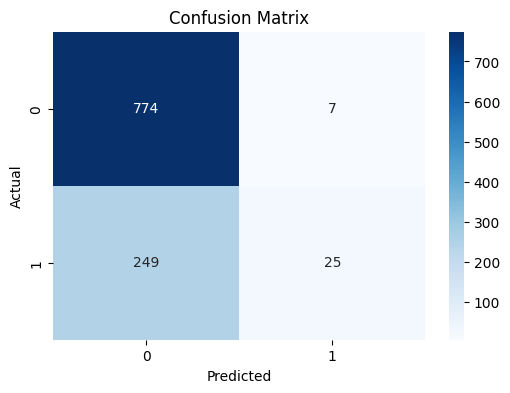

In [79]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6,4))
sns.heatmap(cm, annot=True, fmt='d', cmap="Blues")

plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.show()

## ROC Curve with AUC

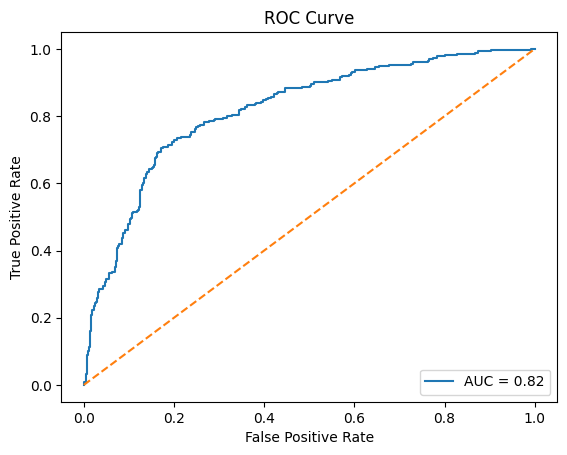

In [80]:
from sklearn.metrics import roc_curve, auc

fpr, tpr, _ = roc_curve(y_test, y_prob)
roc_auc = auc(fpr, tpr)

plt.plot(fpr, tpr, label="AUC = %0.2f" % roc_auc)

plt.plot([0,1],[0,1],'--')

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")

plt.title("ROC Curve")

plt.legend(loc="lower right")

plt.show()

## Precision-Recall Curve

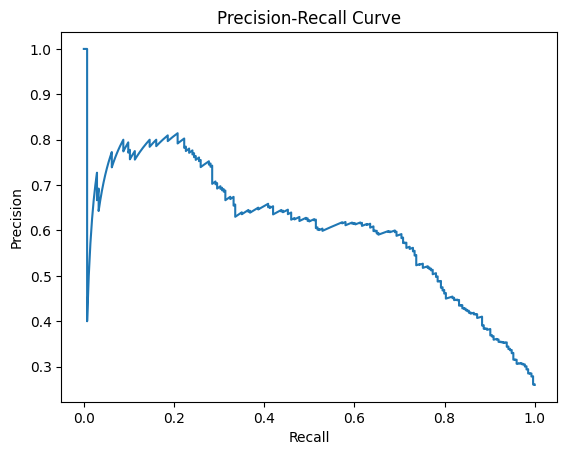

In [83]:
from sklearn.metrics import precision_recall_curve

precision, recall, _ = precision_recall_curve(y_test, y_prob)

plt.plot(recall, precision)

plt.xlabel("Recall")
plt.ylabel("Precision")

plt.title("Precision-Recall Curve")

plt.show()

## Learning Curves

In [86]:
model_final = create_model(
    num_layers=2,
    neurons=64,
    learning_rate=0.001,
    dropout_rate=0.2
)

/home/t4tum/anaconda3/envs/python-starter/lib/python3.11/site-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [87]:
history = model_final.fit(
    X_train,
    y_train,
    validation_split=0.2,
    epochs=20,
    batch_size=32,
    verbose=1
)

Epoch 1/20
124/124 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.6360 - loss: 0.8060 - val_accuracy: 0.7563 - val_loss: 0.6294
Epoch 2/20
124/124 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.9017 - loss: 0.3832 - val_accuracy: 0.7289 - val_loss: 0.6755
Epoch 3/20
124/124 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.9809 - loss: 0.1868 - val_accuracy: 0.6995 - val_loss: 0.7176
Epoch 4/20
124/124 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.9919 - loss: 0.1325 - val_accuracy: 0.7411 - val_loss: 0.7033
Epoch 5/20
124/124 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.9977 - loss: 0.1097 - val_accuracy: 0.6518 - val_loss: 0.7610
Epoch 6/20
124/124 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.9990 - loss: 0.0948 - val_accuracy: 0.7015 - val_loss: 0.7212
Epoch 7/20
124/124 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.9995 - loss: 0.0849 - val_accuracy: 0.7584 - val_loss: 0.6392
Epoch 8/20
124/124 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.9995 - loss: 0.0774 - val_accuracy: 0.

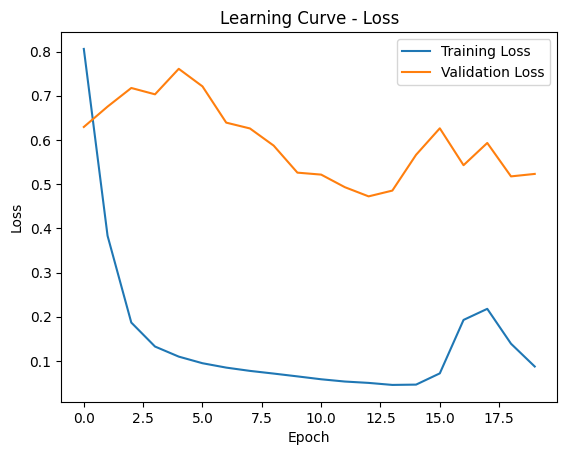

In [88]:
import matplotlib.pyplot as plt

plt.plot(history.history['loss'], label="Training Loss")
plt.plot(history.history['val_loss'], label="Validation Loss")

plt.title("Learning Curve - Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")

plt.legend()
plt.show()

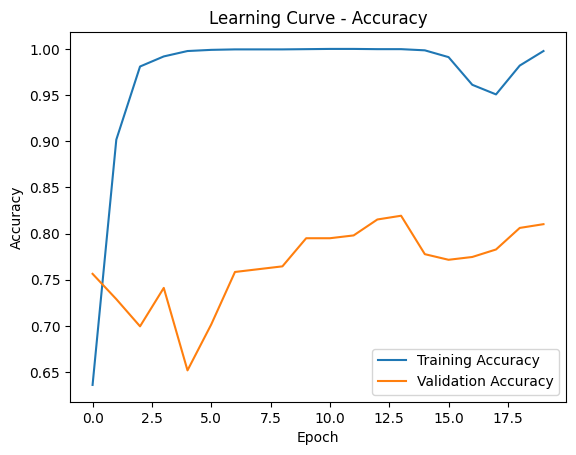

In [89]:
plt.plot(history.history['accuracy'], label="Training Accuracy")
plt.plot(history.history['val_accuracy'], label="Validation Accuracy")

plt.title("Learning Curve - Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")

plt.legend()
plt.show()